# Mean Reversion / Pairs Trading
## Week 4 – Monday 20 April

Today I am choosing a pair and checking whether their prices move together in a way that may support a mean-reversion strategy.

- Understand mean reversion and pairs trading
- One pair chosen for this week's project
- A first visual comparison of the pair
- Short written note explaining why I chose it

## Mean Reversion:
- Mean reversion suggests that asset prices tend to return to average levels, as extreme price moves are hard to sustain for extended periods of time.
- Capitalising on asset's extreme price and it does NOT re-rate. Instead comes backs to its previous state
- In pairs trading, you try to exploit the relationship between two related assets
- The key idea is not to predict direction perfectly, but to trade the deviation from the normal relationship.

Two broad ideas:
- Single-asset mean reversion: one asset moves back toward its own average.
- Pairs trading / spread mean reversion: the relationship between two assets moves away from a normal spread and later converges again.

## Chosen pair
- XLU + XLP
- Secondary Pair (comparison): XLE + XOP

## Pairs Considered & Why Rejected

- SPY + QQQ — ideal beginner pair, liquid and clean data, but already used extensively in prior rolling mean work so limited learning value here
- XLF + XLK — strong macro story (financials vs tech), but current rate uncertainty and risk-off sentiment makes the spread noisy and harder to interpret
- GLD + SLV — classic professional pairs trade, but silver has surged disproportionately due to the Middle East conflict, breaking the historical gold/silver ratio
- XLE + XOP — tight statistical relationship, but the ongoing oil supply shock (Strait of Hormuz closure, prices up 40% YoY) means both ETFs move together, reducing spread divergence and undermining the mean reversion assumption — applied separately as a comparison case

## Why XLU + XLP

- Both are defensive sector ETFs — investors rotate into them together during market stress, creating a naturally stable relationship
- Low-noise spread — fewer independent shocks capable of moving one without the other
- Insulated from the current geopolitical environment (oil shock, Middle East conflict)
- Clean, liquid data — easy to work with for learning the mechanics
- Simple to explain: when they temporarily diverge, they tend to come back together


## Secondary Application — XLE + XOP
The same pairs trading code will be applied to XLE + XOP to observe how the spread behaves under stressed, regime-change conditions — contrasting with the stable spread of our primary pair.

XLU — SPDR Utilities Select Sector ETF
- Tracks the utilities sector of the S&P 500. This includes companies that provide essential services like electricity, gas, and water — think firms like NextEra Energy, Duke Energy, and Southern Company. Because people always need power and water regardless of the economy, utilities are considered a very stable, defensive sector.

XLP — SPDR Consumer Staples Select Sector ETF
- Tracks the consumer staples sector of the S&P 500. This includes companies that sell everyday essential goods — food, drinks, household products, and personal care items. Major holdings include companies like Procter & Gamble, Coca-Cola, and Costco. Again, because people keep buying toothpaste and groceries even in a recession, this is considered another defensive, stable sector.

The key thing that makes them a good pair is that both are "defensive" sectors — meaning when markets get rocky, investors pile into both of them at the same time as a safe haven. That shared behaviour is what creates the stable, predictable relationship that makes them well suited for pairs trading.

## Step 1 - Load data and standarise the price columns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
xlu = pd.read_csv('/Users/Sinthu/Desktop/Quant Trading Project/data/xlu.csv', parse_dates=['Date'], date_format='%m/%d/%y', index_col='Date')   # change if needed

xlu.columns = xlu.columns.str.strip()

xlu = pd.DataFrame({'Adj_Close': xlu['Close']})

xlu.sort_index(inplace=True)
xlu.head()

,Adj_Close
Date,
1998-12-22,14.9141
1998-12-23,14.8516
1998-12-24,15.1250
1998-12-28,15.0469
1998-12-29,15.2969


In [3]:
xlp = pd.read_csv('/Users/Sinthu/Desktop/Quant Trading Project/data/xlp.csv', parse_dates=['Date'], date_format='%m/%d/%y', index_col='Date')   # change if needed

xlp.columns = xlp.columns.str.strip()

xlp = pd.DataFrame({'Adj_Close': xlp['Close']})

xlp.sort_index(inplace=True)
xlp.head()

,Adj_Close
Date,
1998-12-22,26.5000
1998-12-23,27.1406
1998-12-24,27.0938
1998-12-28,26.9375
1998-12-29,27.5313


In [6]:
# Extract adjusted close prices and combine
prices = pd.DataFrame({
    'XLU': xlu['Adj_Close'],  # adjust column name if needed
    'XLP': xlp['Adj_Close']
}).dropna()

print("Combined prices shape:", prices.shape)
print("\nFirst 5 rows:")
prices.head()

Combined prices shape: (6877, 2)

First 5 rows:


,XLU,XLP
Date,,
1998-12-22,14.9141,26.5000
1998-12-23,14.8516,27.1406
1998-12-24,15.1250,27.0938
1998-12-28,15.0469,26.9375
1998-12-29,15.2969,27.5313


## Step 2 - Plot the two price series

<Figure size 1200x600 with 0 Axes>

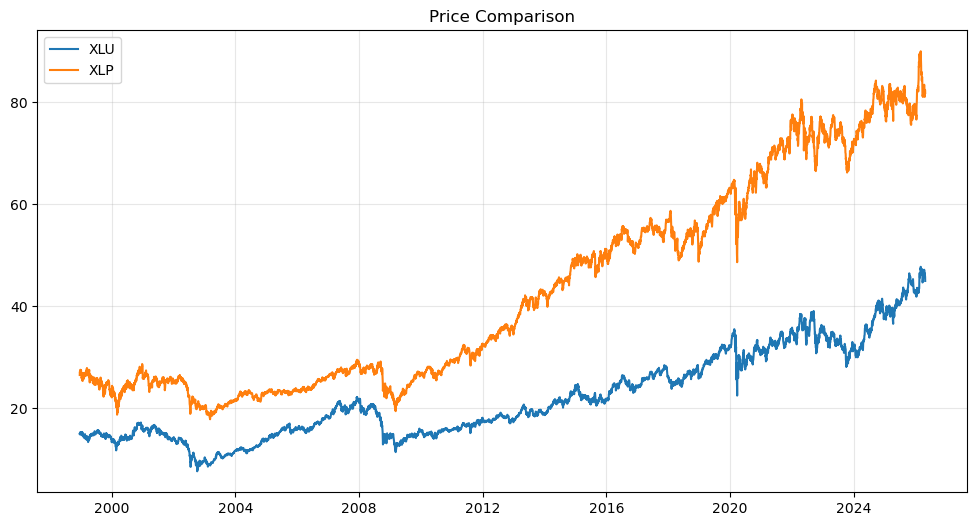

In [8]:
plt.figure(figsize=(12,6))
plt.plot(prices.index, prices["XLU"], label="XLU")
plt.plot(prices.index, prices["XLP"], label="XLP")
plt.title("Price Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## What to look for

Do the prices move in a similar broad direction?
- Yes, clearly noticeable that XLU and XLP - as the graph look identical and just translated in the y-axis
  
Are they visually related?
- Yes

Are there long periods where one clearly diverges from the other?
- After 2008, XLP grows at a faster gradient than XLU, which is noticeable. However, similar price flucations.

## Step 3 - Plot the price ratio

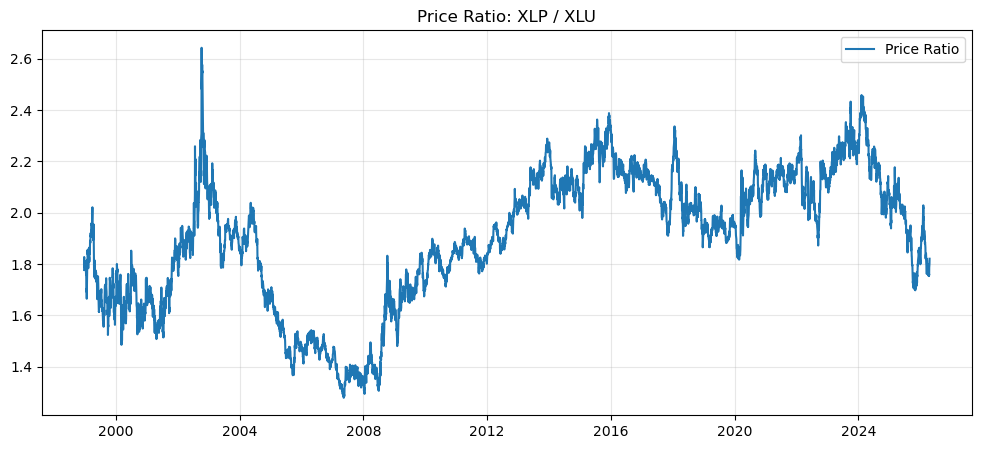

In [12]:
prices["ratio"] = prices["XLP"] / prices["XLU"]

plt.figure(figsize=(12,5))
plt.plot(prices.index, prices["ratio"], label="Price Ratio")
plt.title("Price Ratio: XLP / XLU")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## What the ratio is showing?

The ratio represents how expensive one is relative to the other.

## The two possible outcomes

### Outcome 1 — The ratio trends endlessly upward or downward.

- This means one asset is permanently getting more expensive relative to the other with no sign of coming back. There's no natural "middle ground" the ratio returns to. This pair has no mean reversion relationship — pairs trading won't work here.
- Linear line with no flucations in ratio.

### Outcome 2 — The ratio wobbles around a rough average

- This means whenever Asset 1 gets too expensive relative to Asset 2, it eventually comes back down, and vice versa. The ratio has a "home" it keeps returning to. This is exactly what mean reversion looks like visually — and it's the green light that says this pair might be worth trading.
- Flucations in ratio, going higher & lower than an middle ratio value. The above plot is good example for outcome 2.

## Step 4 - Add a rolling mean to the ratio

Rolling average of the ratio

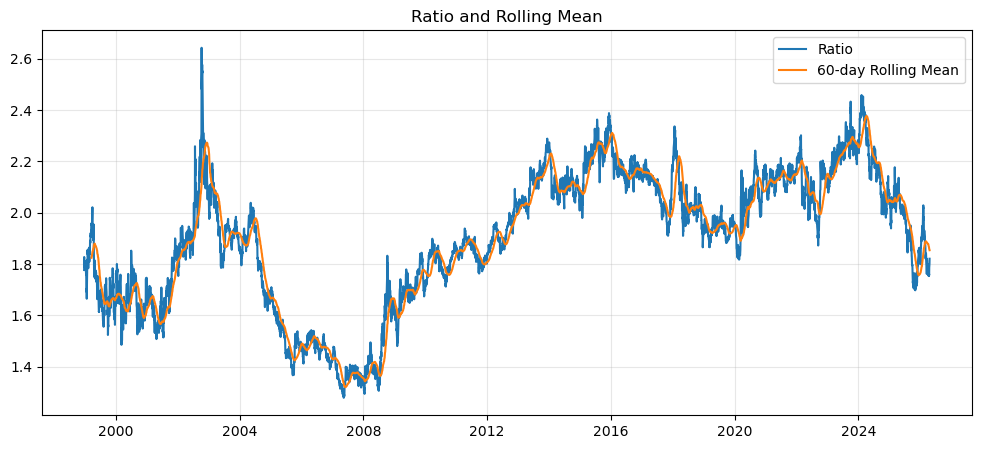

In [14]:
lookback = 60
prices["ratio_mean"] = prices["ratio"].rolling(lookback).mean()

plt.figure(figsize=(12,5))
plt.plot(prices.index, prices["ratio"], label="Ratio")
plt.plot(prices.index, prices["ratio_mean"], label=f"{lookback}-day Rolling Mean")
plt.title("Ratio and Rolling Mean")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Does the ratio move back toward its average?
- Yes, it the ratio moves back towards its average
  
Or does it drift strongly in one direction?
- No, however there are middle periods which shows a combo of a strong in one direction and ratio moving back to its average.

Is the mean itself stable enough to be useful?
- Not entirely, it's noticeable the mean has to change over different period of time.

## First pair judgement

Why did I choose this pair?
- Answered at the beginning, safe ETFs no affected about geopolitical noise and good to learn mean reversion mechanics. 

Does the ratio look roughly mean-reverting?
- Yes
  
Does it look stable enough to explore further?
- Yes, stable two ETFs good to study mean reversion.

Are there any obvious red flags?
- No current red flags, just curious to know about how to calculate the mean. As that will determine the number of trades.

In [16]:
returns = prices[["XLU", "XLP"]].pct_change().dropna()
corr = returns.corr().iloc[0,1]
print(f"Return correlation: {corr:.3f}")

Return correlation: 0.597


Correlation is not the same as cointegration, but it helps you understand whether a pair has some general relationship.